## **2.1 Baseline/PTLM Gap(TF-IDF + Logistic regression vs RoBERTa)**



**2.1.1 Data Loading and Preparation**

This code installs required libraries, sets random seeds for reproducibility, and initializes the computing device.
It mounts Google Drive and loads the preprocessed BESSTIE CSV files.
The data is then converted into a Hugging Face DatasetDict.
Basic dataset structure and distributions are inspected.
This step prepares the dataset for subsequent modeling tasks.

In [ ]:
# ================================
# 1) Install + Imports + Seed + Load Data (CSV version)
# ================================
!pip install -q datasets transformers evaluate scikit-learn accelerate

import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict, Value

# Seed + Device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic = True

print("PyTorch Version:", torch.__version__)
print(f"Using {'GPU' if str(DEVICE) == 'cuda' else 'CPU'}")

# ================================
# Google Drive mount
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# Load cleaned CSV
# ================================
base_path = "/content/drive/MyDrive/NLP CW/"

train_df = pd.read_csv(base_path + "besstie_train_cleaned.csv")
val_df   = pd.read_csv(base_path + "besstie_val_cleaned.csv")
test_df  = pd.read_csv(base_path + "besstie_test_cleaned.csv")

print("\nCSV loaded successfully")
print(train_df.head())

print("\nColumns:")
print(train_df.columns)

print("\nVariety distribution:")
print(train_df["variety"].value_counts())

# ================================
# HuggingFace Dataset
# ================================
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

print("\nConverted to HuggingFace Dataset")
print(dataset)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
PyTorch Version: 2.10.0+cu128
Using GPU
Mounted at /content/drive

CSV loaded successfully
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm                                       cleaned_text  
0        0.0      0.0  i'm a member of the green party but i'll be vo...  
1        0.0      1.0  yeah it blew out to 3x what it was budgeted fo...  
2        1.0      0.0  food was pretty great. a little dry, but i am ...  
3        0.0      0.0  firstly the staff seemed as if they did n't wa...  
4        1.0      0.0  

**2.1.2 Baseline Model and Evaluation Setup**

This code defines evaluation functions and implements a TF-IDF + Logistic Regression baseline.
It computes standard metrics including accuracy and Macro-F1.
Per-variety evaluation is also included to assess robustness across dialects.
The baseline model is trained and evaluated on both sentiment and sarcasm tasks.
This provides a reference point for comparison with more advanced models.

In [ ]:
# ================================
# 2) Evaluation functions + Baseline
# ================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# -----------------------------
# Column names (MATCH YOUR DATA)
# -----------------------------
TEXT_COL = "text"
VARIETY_COL = "variety"
SENT_LABEL_COL = "Sentiment"
SARC_LABEL_COL = "Sarcasm"

# -----------------------------
# Basic metrics
# -----------------------------
def compute_metrics_basic(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

# -----------------------------
# Per-variety evaluation
# -----------------------------
def evaluate_by_variety(df, true_col, pred_col, variety_col=VARIETY_COL):
    results = []
    for v in sorted(df[variety_col].dropna().unique()):
        sub = df[df[variety_col] == v]
        metrics = compute_metrics_basic(sub[true_col], sub[pred_col])
        metrics["variety"] = v
        metrics["n_samples"] = len(sub)
        results.append(metrics)
    return pd.DataFrame(results)

# -----------------------------
# Detailed metrics (CM + report)
# -----------------------------
def get_detailed_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return cm, pd.DataFrame(report).transpose()

# -----------------------------
# TF-IDF + Logistic Regression
# -----------------------------
def run_tfidf_logreg(train_df, val_df, test_df, label_col, text_col=TEXT_COL):
    X_train = train_df[text_col].fillna("").astype(str)
    y_train = train_df[label_col].astype(int)

    X_val = val_df[text_col].fillna("").astype(str)
    y_val = val_df[label_col].astype(int)

    X_test = test_df[text_col].fillna("").astype(str)
    y_test = test_df[label_col].astype(int)

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        min_df=2
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)
    X_test_tfidf = vectorizer.transform(X_test)

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_train_tfidf, y_train)

    val_pred = clf.predict(X_val_tfidf)
    test_pred = clf.predict(X_test_tfidf)

    result_df = test_df.copy()
    result_df["pred"] = test_pred
    result_df["true"] = y_test.values

    confusion_mat, class_report = get_detailed_metrics(result_df["true"], result_df["pred"])

    return {
        "label_col": label_col,
        "vectorizer": vectorizer,
        "model": clf,
        "val_metrics": compute_metrics_basic(y_val, val_pred),
        "test_metrics": compute_metrics_basic(y_test, test_pred),
        "per_variety": evaluate_by_variety(result_df, "true", "pred", variety_col=VARIETY_COL),
        "confusion_matrix": confusion_mat,
        "classification_report": class_report,
        "test_predictions": result_df
    }

# -----------------------------
# Run baseline (both tasks)
# -----------------------------
sent_baseline = run_tfidf_logreg(train_df, val_df, test_df, SENT_LABEL_COL)
sarc_baseline = run_tfidf_logreg(train_df, val_df, test_df, SARC_LABEL_COL)

# -----------------------------
# Print results
# -----------------------------
print("Sentiment baseline (val):", sent_baseline["val_metrics"])
print("Sentiment baseline (test):", sent_baseline["test_metrics"])

print("Sarcasm baseline (val):", sarc_baseline["val_metrics"])
print("Sarcasm baseline (test):", sarc_baseline["test_metrics"])

Sentiment baseline (val): {'accuracy': 0.853035143769968, 'macro_precision': 0.8533039287756269, 'macro_recall': 0.853390522875817, 'macro_f1': 0.8530336436387391}
Sentiment baseline (test): {'accuracy': 0.8245533669262483, 'macro_precision': 0.8254621518248078, 'macro_recall': 0.823868627605772, 'macro_f1': 0.8241387237910982}
Sarcasm baseline (val): {'accuracy': 0.7731629392971247, 'macro_precision': 0.6300287356321839, 'macro_recall': 0.706446434606286, 'macro_f1': 0.6451417165668663}
Sarcasm baseline (test): {'accuracy': 0.7604214383875401, 'macro_precision': 0.61320313541414, 'macro_recall': 0.6808795544614955, 'macro_f1': 0.6249492057704216}


**2.1.3 RoBERTa Data Processing and Tokenization**

This code sets up the RoBERTa tokenizer and prepares the dataset for transformer-based training.
It converts the data into Hugging Face format and applies tokenization.
Labels are standardized for compatibility with the Trainer API.
A custom evaluation function using Macro-F1 is defined.
This step prepares the data pipeline for fine-tuning RoBERTa.

In [ ]:
# ================================
# 3) RoBERTa setup + tokenization + metrics
# ================================
import numpy as np
from datasets import Dataset, DatasetDict, Value
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

# -----------------------------
# Prepare Hugging Face dataset
# -----------------------------
def build_datasetdict(train_df, val_df, test_df, label_col, text_col=TEXT_COL, variety_col=VARIETY_COL):
    train_sub = train_df[[text_col, variety_col, label_col]].copy().dropna(subset=[text_col, label_col])
    val_sub   = val_df[[text_col, variety_col, label_col]].copy().dropna(subset=[text_col, label_col])
    test_sub  = test_df[[text_col, variety_col, label_col]].copy().dropna(subset=[text_col, label_col])

    train_sub[label_col] = train_sub[label_col].astype(int)
    val_sub[label_col]   = val_sub[label_col].astype(int)
    test_sub[label_col]  = test_sub[label_col].astype(int)

    dataset = DatasetDict({
        "train": Dataset.from_pandas(train_sub.reset_index(drop=True)),
        "validation": Dataset.from_pandas(val_sub.reset_index(drop=True)),
        "test": Dataset.from_pandas(test_sub.reset_index(drop=True))
    })
    return dataset

# -----------------------------
# Tokenization
# -----------------------------
def tokenize_function(examples):
    return tokenizer(
        examples[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )

def prepare_hf_dataset(dataset, label_col):
    ds = dataset.rename_column(label_col, "labels")
    ds = ds.cast_column("labels", Value("int64"))

    tokenized = ds.map(tokenize_function, batched=True)

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )
    return tokenized

# -----------------------------
# Metrics for Trainer
# -----------------------------
def compute_metrics_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

print("RoBERTa helper functions ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: roberta-base
RoBERTa helper functions ready


**2.1.4 RoBERTa Fine-tuning**

This code defines the fine-tuning procedure for RoBERTa.
It builds datasets, tokenizes inputs, and initializes the classification model.
Training arguments such as batch size, learning rate, and epochs are configured.
The Hugging Face Trainer is used to train the model.
This step produces fine-tuned models for each task.

In [ ]:
# ================================
# 4) RoBERTa fine-tuning function
# ================================
import torch

def train_roberta_for_task(train_df, val_df, test_df, label_col):
    print("\n" + "=" * 40)
    print(f"Running RoBERTa for task: {label_col}")
    print("=" * 40)

    # 1) Build dataset
    dataset = build_datasetdict(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_col=label_col,
        text_col=TEXT_COL,
        variety_col=VARIETY_COL
    )

    # 2) Tokenize
    tokenized_dataset = prepare_hf_dataset(dataset, label_col)

    print(tokenized_dataset)

    # 3) Model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    model.config.problem_type = "single_label_classification"

    output_dir = f"./roberta_{label_col.lower()}"

    # 4) Training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        learning_rate=2e-5,
        weight_decay=0.01,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=42
    )

    # 5) Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics_trainer
    )

    # 6) Train
    trainer.train()

    print(f"Training finished for {label_col}")

    return {
        "label_col": label_col,
        "dataset": dataset,
        "tokenized_dataset": tokenized_dataset,
        "model": model,
        "trainer": trainer
    }

**2.1.5 Model Evaluation and Comparison**

This code evaluates the fine-tuned RoBERTa model on the test set.
Predictions are generated and compared with ground truth labels.
Performance is measured using Macro-F1 and per-variety analysis.
Confusion matrices and classification reports are also produced.
Finally, results are compared with the baseline model in a summary table

In [ ]:
# ================================
# 5) Test evaluation + comparison with baseline
# Output-minimised version
# ================================

def get_test_predictions_from_trainer(trainer, original_test_df, tokenized_test_dataset, label_col):
    preds_output = trainer.predict(tokenized_test_dataset)
    logits = preds_output.predictions
    preds = np.argmax(logits, axis=1)

    result_df = original_test_df.copy()
    result_df["pred"] = preds
    result_df["true"] = result_df[label_col].astype(int)

    overall = compute_metrics_basic(result_df["true"], result_df["pred"])
    per_variety = evaluate_by_variety(result_df, true_col="true", pred_col="pred")
    confusion_mat, class_report = get_detailed_metrics(result_df["true"], result_df["pred"])

    return overall, per_variety, result_df, confusion_mat, class_report


def evaluate_roberta_result(roberta_run, test_df, label_col, baseline_metrics):
    trainer = roberta_run["trainer"]
    tokenized_test_dataset = roberta_run["tokenized_dataset"]["test"]

    # Trainer evaluation result
    test_eval = trainer.evaluate(tokenized_test_dataset)

    # Manual prediction-based evaluation
    roberta_overall, roberta_per_variety, roberta_result_df, roberta_cm, roberta_report = (
        get_test_predictions_from_trainer(
            trainer=trainer,
            original_test_df=test_df,
            tokenized_test_dataset=tokenized_test_dataset,
            label_col=label_col
        )
    )

    # Baseline vs RoBERTa comparison for this task
    comparison_df = pd.DataFrame([
        {
            "task": label_col.lower(),
            "model": "TF-IDF + Logistic Regression",
            **baseline_metrics
        },
        {
            "task": label_col.lower(),
            "model": "RoBERTa-base",
            **roberta_overall
        }
    ])

    return {
        "test_eval": test_eval,
        "overall": roberta_overall,
        "per_variety": roberta_per_variety,
        "result_df": roberta_result_df,
        "confusion_matrix": roberta_cm,
        "classification_report": roberta_report,
        "comparison_df": comparison_df
    }


# -----------------------------
# Run RoBERTa for both tasks
# -----------------------------
roberta_sent = train_roberta_for_task(train_df, val_df, test_df, SENT_LABEL_COL)
roberta_sarc = train_roberta_for_task(train_df, val_df, test_df, SARC_LABEL_COL)


# -----------------------------
# Evaluate Sentiment
# -----------------------------
sent_results = evaluate_roberta_result(
    roberta_run=roberta_sent,
    test_df=test_df,
    label_col=SENT_LABEL_COL,
    baseline_metrics=sent_baseline["test_metrics"]
)


# -----------------------------
# Evaluate Sarcasm
# -----------------------------
sarc_results = evaluate_roberta_result(
    roberta_run=roberta_sarc,
    test_df=test_df,
    label_col=SARC_LABEL_COL,
    baseline_metrics=sarc_baseline["test_metrics"]
)


print("RoBERTa training and evaluation completed.")
print("Detailed report tables will be generated in Cell 6.")


Running RoBERTa for task: Sentiment


Casting the dataset:   0%|          | 0/3747 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/313 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training finished for Sarcasm


RoBERTa training and evaluation completed.
Detailed report tables will be generated in Cell 6.


Section 3: Evaluation : overall metrics, per-class report, per-variety, confusion matrix, majority-class check.




=== Table 1. Overall Evaluation Metrics ===


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Sentiment,TF-IDF + Logistic Regression,0.8246,0.8255,0.8239,0.8241
1,Sentiment,RoBERTa-base,0.8942,0.8947,0.8937,0.8940
2,Sarcasm,TF-IDF + Logistic Regression,0.7604,0.6132,0.6809,0.6249
3,Sarcasm,RoBERTa-base,0.8690,0.7244,0.6575,0.6814



=== Table 2. Per-Class Evaluation Metrics: Best RoBERTa Models ===


,Task,Class,Precision,Recall,F1-score,Support
0,Sentiment,Negative,0.8845,0.9123,0.8982,1117
1,Sentiment,Positive,0.9049,0.8752,0.8898,1066
2,Sarcasm,Non-sarcasm,0.9020,0.9510,0.9259,1878
3,Sarcasm,Sarcasm,0.5468,0.3639,0.4370,305



=== Table 3. Per-Variety Evaluation Metrics: RoBERTa ===


,Task,Model,Variety,N,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Sentiment,RoBERTa-base,en-AU,667,0.8966,0.9021,0.8943,0.8957
1,Sentiment,RoBERTa-base,en-IN,816,0.8529,0.8527,0.8522,0.8524
2,Sentiment,RoBERTa-base,en-UK,700,0.9400,0.9401,0.9398,0.9399
3,Sarcasm,RoBERTa-base,en-AU,667,0.7826,0.7630,0.6733,0.6918
4,Sarcasm,RoBERTa-base,en-IN,816,0.9093,0.5440,0.5212,0.5249
5,Sarcasm,RoBERTa-base,en-UK,700,0.9043,0.6780,0.7230,0.6969



=== Table 4. Majority-Class Prediction Check ===


,Task,Class,True Count,Predicted Count
0,Sentiment,Negative,1117,1152
1,Sentiment,Positive,1066,1031
2,Sarcasm,Non-sarcasm,1878,1980
3,Sarcasm,Sarcasm,305,203



=== Figure 1. Confusion Matrix: Sentiment RoBERTa ===


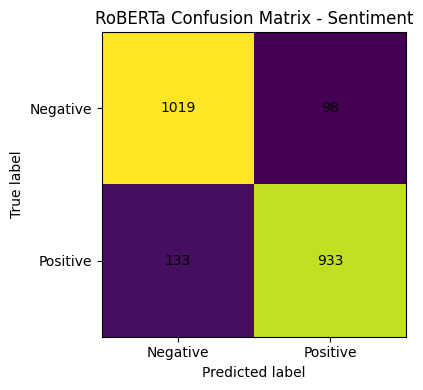


=== Figure 2. Confusion Matrix: Sarcasm RoBERTa ===


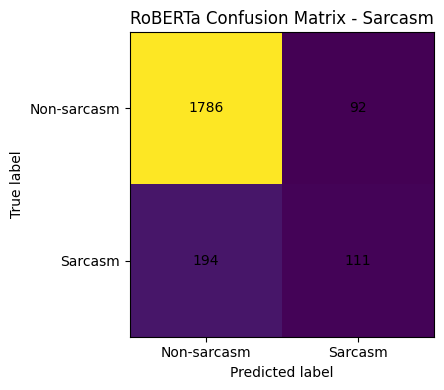


Saved CSV files:
- section3_overall_metrics.csv
- section3_per_class_metrics.csv
- section3_per_variety_metrics.csv
- section3_majority_class_check.csv


In [ ]:
# ================================
# 6) Section 3 Evaluation Extractor
# Report-ready output only
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


# -----------------------------
# Helper: overall metric table
# -----------------------------
def make_overall_table():
    rows = [
        {
            "Task": "Sentiment",
            "Model": "TF-IDF + Logistic Regression",
            **sent_baseline["test_metrics"]
        },
        {
            "Task": "Sentiment",
            "Model": "RoBERTa-base",
            **sent_results["overall"]
        },
        {
            "Task": "Sarcasm",
            "Model": "TF-IDF + Logistic Regression",
            **sarc_baseline["test_metrics"]
        },
        {
            "Task": "Sarcasm",
            "Model": "RoBERTa-base",
            **sarc_results["overall"]
        }
    ]

    df = pd.DataFrame(rows)

    df = df.rename(columns={
        "accuracy": "Accuracy",
        "macro_precision": "Macro Precision",
        "macro_recall": "Macro Recall",
        "macro_f1": "Macro F1"
    })

    metric_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
    df[metric_cols] = df[metric_cols].round(4)

    return df


# -----------------------------
# Helper: per-class report
# -----------------------------
def make_per_class_table(result_df, true_col="true", pred_col="pred", task_name="Task"):
    report = classification_report(
        result_df[true_col],
        result_df[pred_col],
        output_dict=True,
        zero_division=0
    )

    df = pd.DataFrame(report).transpose().reset_index()
    df = df.rename(columns={"index": "Class"})

    df = df[df["Class"].isin(["0", "1"])].copy()

    if task_name.lower() == "sentiment":
        class_map = {
            "0": "Negative",
            "1": "Positive"
        }
    elif task_name.lower() == "sarcasm":
        class_map = {
            "0": "Non-sarcasm",
            "1": "Sarcasm"
        }
    else:
        class_map = {
            "0": "Class 0",
            "1": "Class 1"
        }

    df["Class"] = df["Class"].map(class_map)
    df["Task"] = task_name

    df = df[["Task", "Class", "precision", "recall", "f1-score", "support"]]
    df = df.rename(columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-score",
        "support": "Support"
    })

    df[["Precision", "Recall", "F1-score"]] = df[["Precision", "Recall", "F1-score"]].round(4)
    df["Support"] = df["Support"].astype(int)

    return df


# -----------------------------
# Helper: per-variety table
# -----------------------------
def clean_per_variety_table(per_variety_df, task_name, model_name):
    df = per_variety_df.copy()

    df["Task"] = task_name
    df["Model"] = model_name

    df = df.rename(columns={
        "variety": "Variety",
        "accuracy": "Accuracy",
        "macro_precision": "Macro Precision",
        "macro_recall": "Macro Recall",
        "macro_f1": "Macro F1",
        "n_samples": "N"
    })

    df = df[[
        "Task", "Model", "Variety", "N",
        "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"
    ]]

    metric_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
    df[metric_cols] = df[metric_cols].round(4)

    return df


# -----------------------------
# Helper: confusion matrix plot
# -----------------------------
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5, 4))

    ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


# -----------------------------
# Helper: majority-class check
# -----------------------------
def majority_class_check(result_df, task_name):
    pred_counts = result_df["pred"].value_counts().sort_index()
    true_counts = result_df["true"].value_counts().sort_index()

    df = pd.DataFrame({
        "True Count": true_counts,
        "Predicted Count": pred_counts
    }).fillna(0).astype(int)

    if task_name.lower() == "sentiment":
        df.index = ["Negative" if i == 0 else "Positive" for i in df.index]
    elif task_name.lower() == "sarcasm":
        df.index = ["Non-sarcasm" if i == 0 else "Sarcasm" for i in df.index]

    df["Task"] = task_name
    df = df.reset_index().rename(columns={"index": "Class"})

    return df[["Task", "Class", "True Count", "Predicted Count"]]


# ================================
# 1) Overall metric table
# ================================
overall_table = make_overall_table()

print("\n=== Table 1. Overall Evaluation Metrics ===")
display(overall_table)


# ================================
# 2) Per-class results for best RoBERTa models
# ================================
sent_per_class = make_per_class_table(
    sent_results["result_df"],
    task_name="Sentiment"
)

sarc_per_class = make_per_class_table(
    sarc_results["result_df"],
    task_name="Sarcasm"
)

per_class_table = pd.concat(
    [sent_per_class, sarc_per_class],
    ignore_index=True
)

print("\n=== Table 2. Per-Class Evaluation Metrics: Best RoBERTa Models ===")
display(per_class_table)


# ================================
# 3) Per-variety results for RoBERTa
# ================================
sent_variety_table = clean_per_variety_table(
    sent_results["per_variety"],
    task_name="Sentiment",
    model_name="RoBERTa-base"
)

sarc_variety_table = clean_per_variety_table(
    sarc_results["per_variety"],
    task_name="Sarcasm",
    model_name="RoBERTa-base"
)

per_variety_table = pd.concat(
    [sent_variety_table, sarc_variety_table],
    ignore_index=True
)

print("\n=== Table 3. Per-Variety Evaluation Metrics: RoBERTa ===")
display(per_variety_table)


# ================================
# 4) Majority-class prediction check
# ================================
sent_majority_check = majority_class_check(
    sent_results["result_df"],
    task_name="Sentiment"
)

sarc_majority_check = majority_class_check(
    sarc_results["result_df"],
    task_name="Sarcasm"
)

majority_check_table = pd.concat(
    [sent_majority_check, sarc_majority_check],
    ignore_index=True
)

print("\n=== Table 4. Majority-Class Prediction Check ===")
display(majority_check_table)


# ================================
# 5) Confusion matrices for best models
# ================================
print("\n=== Figure 1. Confusion Matrix: Sentiment RoBERTa ===")
plot_confusion_matrix(
    sent_results["confusion_matrix"],
    class_names=["Negative", "Positive"],
    title="RoBERTa Confusion Matrix - Sentiment"
)

print("\n=== Figure 2. Confusion Matrix: Sarcasm RoBERTa ===")
plot_confusion_matrix(
    sarc_results["confusion_matrix"],
    class_names=["Non-sarcasm", "Sarcasm"],
    title="RoBERTa Confusion Matrix - Sarcasm"
)


# ================================
# 6) Save tables as CSV for report
# ================================
overall_table.to_csv("section3_overall_metrics.csv", index=False)
per_class_table.to_csv("section3_per_class_metrics.csv", index=False)
per_variety_table.to_csv("section3_per_variety_metrics.csv", index=False)
majority_check_table.to_csv("section3_majority_class_check.csv", index=False)

print("\nSaved CSV files:")
print("- section3_overall_metrics.csv")
print("- section3_per_class_metrics.csv")
print("- section3_per_variety_metrics.csv")
print("- section3_majority_class_check.csv")